# SVD Grid Search chọn `n_factors` (k) cho bài toán Top-N

Notebook này chỉ làm:
1) Đọc dữ liệu MovieLens (u.data + u.item)
2) Chạy `SVD(n_factors=...)` theo grid search
3) Đánh giá trên tập test bằng `Recall@k` và `NDCG@k`
4) Chọn `n_factors` tối ưu theo `NDCG@10`


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, SVD
from sklearn.model_selection import KFold


In [2]:
# ====== Cấu hình ======
LOCAL_DATA_DIR = "."
KAGGLE_DATA_DIR = "/kaggle/input/datasets/truongnhatnguyen2805/movielens-v5"

if os.path.exists(os.path.join(LOCAL_DATA_DIR, "u.data")) and os.path.exists(
    os.path.join(LOCAL_DATA_DIR, "u.item")
):
    DATA_DIR = LOCAL_DATA_DIR
elif os.path.isdir(KAGGLE_DATA_DIR):
    DATA_DIR = KAGGLE_DATA_DIR
else:
    raise FileNotFoundError(
        "Không tìm thấy u.data và u.item. Hãy đặt 2 file cùng thư mục với notebook hoặc mount Kaggle dataset."
    )

RANDOM_STATE = 42
N_FOLDS = 3            
EVAL_USERS = 50      

K_COMPARE = [1, 3, 5, 10]

# Grid search cho n_factors (k) của SVD
N_FACTORS_GRID = [10, 20, 30,40,50, 60,70, 80,90, 100]


SVD_N_EPOCHS = 25
SVD_LR_ALL = 0.005
SVD_REG_ALL = 0.02

# Relevant nếu rating >= threshold
RELEVANT_THRESHOLD = 4.0

print("DATA_DIR =", DATA_DIR)
print("N_FACTORS_GRID =", N_FACTORS_GRID)


DATA_DIR = .
N_FACTORS_GRID = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


In [3]:
# ====== Đọc dữ liệu MovieLens 100K ======
rating_cols = ["userId", "movieId", "rating", "timestamp"]
ratings = pd.read_csv(
    os.path.join(DATA_DIR, "u.data"),
    sep="\t",
    names=rating_cols,
    engine="python",
)

item_cols = [
    "movieId", "title", "release_date", "video_release_date", "imdb_url",
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
    "Romance", "Sci-Fi", "Thriller", "War", "Western",
]
items = pd.read_csv(
    os.path.join(DATA_DIR, "u.item"),
    sep="|",
    names=item_cols,
    encoding="latin-1",
    engine="python",
)

ratings["rating"] = ratings["rating"].astype(float)
all_movie_ids = items["movieId"].astype(int).tolist()

print(
    f"Ratings shape: {ratings.shape} | Users: {ratings['userId'].nunique()} | Movies: {ratings['movieId'].nunique()}"
)
print("All movies:", len(all_movie_ids))


Ratings shape: (100000, 4) | Users: 943 | Movies: 1682
All movies: 1682


In [9]:
from IPython.display import display

display(ratings.head())
display(items.head())

# Dem so danh gia cua moi phim (theo movieId)
film_rating_counts = (
    ratings.groupby("movieId").size().reset_index(name="rating_count")
    .sort_values("rating_count", ascending=False)
)
display(film_rating_counts)

,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


,movieId,title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


,movieId,rating_count
49,50,583
257,258,509
99,100,508
180,181,507
293,294,485
...,...,...
1575,1576,1
1576,1577,1
1347,1348,1
1578,1579,1


In [5]:
# ====== Metric functions ======
def recall_at_k(rank_list, relevant, k):
    """Recall@K: tỷ lệ relevant xuất hiện trong Top-K."""
    if not relevant:
        return np.nan
    hit = len(set(rank_list[:k]) & relevant)
    return hit / len(relevant)

def dcg_u_at_top_n(rank_list, test_rating_by_movie, n):
    acc = 0.0
    upto = min(n, len(rank_list))
    for i in range(1, upto + 1):
        mid = int(rank_list[i - 1])
        r = float(test_rating_by_movie.get(mid, 0.0))
        acc += (2.0 ** r - 1.0) / np.log(1.0 + i)
    return acc

def idcg_u_at_top_n(test_rating_by_movie, n):
    rels = list(test_rating_by_movie.values())
    if not rels:
        return 0.0
    rels = sorted(rels, reverse=True)[:n]
    acc = 0.0
    for i in range(1, len(rels) + 1):
        r = rels[i - 1]
        acc += (2.0 ** r - 1.0) / np.log(1.0 + i)
    return acc

def ndcg_u_at_top_n(rank_list, test_rating_by_movie, n):
    d = dcg_u_at_top_n(rank_list, test_rating_by_movie, n)
    ideal = idcg_u_at_top_n(test_rating_by_movie, n)
    if ideal < 1e-12:
        return np.nan
    return d / ideal


In [6]:
def evaluate_fold_svd(train_df, test_df, n_factors, fold_id):
    """Train SVD trên train_df, rồi đánh giá NDCG/Recall trên một subset user trong test_df."""
    reader = Reader(rating_scale=(1, 5))
    train_surprise = Dataset.load_from_df(train_df[["userId", "movieId", "rating"]], reader)
    trainset = train_surprise.build_full_trainset()

    svd = SVD(
        n_factors=n_factors,
        n_epochs=SVD_N_EPOCHS,
        lr_all=SVD_LR_ALL,
        reg_all=SVD_REG_ALL,
        random_state=RANDOM_STATE,
    )
    svd.fit(trainset)

    # chọn một tập user để đánh giá (giảm thời gian)
    cand_users = test_df["userId"].unique()
    rng = np.random.RandomState(RANDOM_STATE + fold_id)
    n_pick = min(EVAL_USERS, len(cand_users))
    eval_users = rng.choice(cand_users, size=n_pick, replace=False)

    ndcg_acc = {k: [] for k in K_COMPARE}
    recall_acc = {k: [] for k in K_COMPARE}

    # Precompute inner item ids cho fold hiện tại
    movie_to_inner = {}
    for m in all_movie_ids:
        m = int(m)
        try:
            movie_to_inner[m] = trainset.to_inner_iid(m)
        except ValueError:
            movie_to_inner[m] = None

    for u in eval_users:
        u = int(u)
        seen = set(train_df.loc[train_df["userId"] == u, "movieId"].astype(int))

        # relevant (nhãn) dùng rating >= threshold
        relevant = set(
            test_df.loc[
                (test_df["userId"] == u) & (test_df["rating"] >= RELEVANT_THRESHOLD),
                "movieId",
            ].astype(int)
        )
        relevant = {m for m in relevant if m not in seen}

        # ground-truth có rating để tính NDCG (graded relevance)
        tu = test_df.loc[test_df["userId"] == u, ["movieId", "rating"]]
        test_rating_by_movie = dict(zip(tu["movieId"].astype(int), tu["rating"].astype(float)))
        if not test_rating_by_movie:
            continue

        # Candidates: tất cả item chưa seen
        candidates = [m for m in all_movie_ids if int(m) not in seen]

        scored = None
        try:
            uid_inner = trainset.to_inner_uid(u)

            # Dự đoán theo latent factors: mean + bu + bi + dot(pu, qi)
            bu_val = float(svd.bu[uid_inner])
            pu_vec = svd.pu[uid_inner]  # (n_factors,)

            # phân tách item có/không có trong train fold
            known_movies = [m for m in candidates if movie_to_inner.get(int(m)) is not None]
            unk_movies = [m for m in candidates if movie_to_inner.get(int(m)) is None]

            known_inner = np.array([movie_to_inner[int(m)] for m in known_movies], dtype=int)
            scores_known = (
                svd.global_mean
                + bu_val
                + svd.bi[known_inner]
                + np.dot(svd.qi[known_inner], pu_vec)
            )

            score_unknown = float(svd.global_mean + bu_val)
            scored = list(zip([int(m) for m in known_movies], scores_known.tolist())) + [
                (int(m), score_unknown) for m in unk_movies
            ]
        except Exception:
            # Fallback: nếu không truy cập được latent factors thì dùng predict (chậm hơn)
            scored = [(int(m), svd.predict(u, int(m)).est) for m in candidates]

        scored.sort(key=lambda x: -x[1])
        rank_list = [m for m, _ in scored]

        for kk in K_COMPARE:
            ndcg_acc[kk].append(ndcg_u_at_top_n(rank_list, test_rating_by_movie, kk))
            recall_acc[kk].append(recall_at_k(rank_list, relevant, kk))

    metrics = {}
    for kk in K_COMPARE:
        metrics[f"NDCG@{kk}"] = float(np.nanmean(ndcg_acc[kk]))
        metrics[f"Recall@{kk}"] = float(np.nanmean(recall_acc[kk]))
    return metrics


In [7]:
# ====== Grid search chọn n_factors ======
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
ratings_reset = ratings.reset_index(drop=True)

rows = []

for n_factors in N_FACTORS_GRID:
    fold_metrics = []
    print(f"\n=== Grid: n_factors = {n_factors} ===")
    for fold_id, (train_idx, test_idx) in enumerate(kf.split(ratings_reset), start=1):
        train_df = ratings_reset.iloc[train_idx]
        test_df = ratings_reset.iloc[test_idx]
        print(f"Fold {fold_id}/{N_FOLDS} | train={len(train_df)} | test={len(test_df)}")
        metrics = evaluate_fold_svd(train_df, test_df, n_factors=n_factors, fold_id=fold_id)
        fold_metrics.append(metrics)

    for kk in K_COMPARE:
        ndcg_vals = [fm[f"NDCG@{kk}"] for fm in fold_metrics]
        recall_vals = [fm[f"Recall@{kk}"] for fm in fold_metrics]
        rows.append(
            {
                "n_factors": n_factors,
                "k": kk,
                "NDCG_mean": float(np.mean(ndcg_vals)),
                "NDCG_std": float(np.std(ndcg_vals)),
                "Recall_mean": float(np.mean(recall_vals)),
                "Recall_std": float(np.std(recall_vals)),
            }
        )

df_res = pd.DataFrame(rows)
df_pivot_ndcg = df_res.pivot(index="n_factors", columns="k", values="NDCG_mean").sort_index()
df_pivot_recall = df_res.pivot(index="n_factors", columns="k", values="Recall_mean").sort_index()

print("\n===== NDCG mean theo n_factors =====")
display(df_pivot_ndcg)
print("\n===== Recall mean theo n_factors =====")
display(df_pivot_recall)



=== Grid: n_factors = 10 ===
Fold 1/3 | train=66666 | test=33334
Fold 2/3 | train=66667 | test=33333
Fold 3/3 | train=66667 | test=33333

=== Grid: n_factors = 20 ===
Fold 1/3 | train=66666 | test=33334
Fold 2/3 | train=66667 | test=33333
Fold 3/3 | train=66667 | test=33333

=== Grid: n_factors = 30 ===
Fold 1/3 | train=66666 | test=33334
Fold 2/3 | train=66667 | test=33333
Fold 3/3 | train=66667 | test=33333

=== Grid: n_factors = 40 ===
Fold 1/3 | train=66666 | test=33334
Fold 2/3 | train=66667 | test=33333
Fold 3/3 | train=66667 | test=33333

=== Grid: n_factors = 50 ===
Fold 1/3 | train=66666 | test=33334
Fold 2/3 | train=66667 | test=33333
Fold 3/3 | train=66667 | test=33333

=== Grid: n_factors = 60 ===
Fold 1/3 | train=66666 | test=33334
Fold 2/3 | train=66667 | test=33333
Fold 3/3 | train=66667 | test=33333

=== Grid: n_factors = 70 ===
Fold 1/3 | train=66666 | test=33334
Fold 2/3 | train=66667 | test=33333
Fold 3/3 | train=66667 | test=33333

=== Grid: n_factors = 80 ===
Fold

k,1,3,5,10
n_factors,,,,
10,0.083441,0.097248,0.095098,0.091197
20,0.092688,0.095782,0.093680,0.090154
30,0.107527,0.099996,0.097076,0.094380
40,0.119355,0.108378,0.110530,0.106579
50,0.167097,0.134927,0.121167,0.109293
60,0.108172,0.099082,0.101141,0.099606
70,0.135484,0.116889,0.107365,0.101011
80,0.103871,0.102239,0.090933,0.088231
90,0.138710,0.115209,0.101637,0.097956



===== Recall mean theo n_factors =====


k,1,3,5,10
n_factors,,,,
10,0.004305,0.015674,0.025679,0.043636
20,0.003856,0.013162,0.022408,0.042420
30,0.005589,0.016052,0.025889,0.045871
40,0.006311,0.017286,0.030452,0.049307
50,0.007799,0.022312,0.030090,0.045639
60,0.005721,0.015207,0.027248,0.052344
70,0.008054,0.017628,0.025876,0.047634
80,0.004092,0.014282,0.019188,0.041269
90,0.006052,0.019099,0.025273,0.047771



>>> Best n_factors theo NDCG@10: 50 (mean=0.109293, std=0.010754)


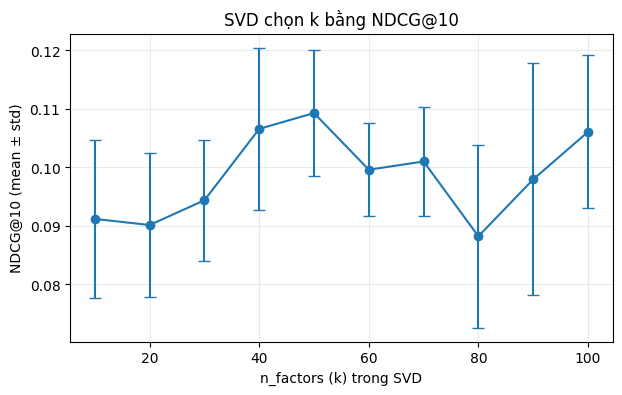

In [8]:
# ====== Chọn best theo NDCG@10 ======
best_k = 10
tmp = df_res[df_res["k"] == best_k].sort_values("NDCG_mean", ascending=False)
best_row = tmp.iloc[0]
best_n_factors = int(best_row["n_factors"])

print(
    f"\n>>> Best n_factors theo NDCG@{best_k}: {best_n_factors} "
    f"(mean={best_row['NDCG_mean']:.6f}, std={best_row['NDCG_std']:.6f})"
)

# Plot NDCG@10 vs n_factors
plot_df = tmp.sort_values("n_factors")
plt.figure(figsize=(7, 4))
plt.errorbar(
    plot_df["n_factors"],
    plot_df["NDCG_mean"],
    yerr=plot_df["NDCG_std"],
    fmt="-o",
    capsize=4,
)
plt.xlabel("n_factors (k) trong SVD")
plt.ylabel(f"NDCG@{best_k} (mean ± std)")
plt.title("SVD chọn k bằng NDCG@10")
plt.grid(True, alpha=0.25)
plt.show()
